# Phase 3 — Traditional ML Training (Colab-Ready, TF-IDF)

**Key fixes + TF-IDF upgrade:**
1. LR: `liblinear` solver (correct for high-dim sparse text)
2. SVM: `cv='prefit'` calibration — no inner CV loops, no collapse
3. TF-IDF features replace OHE as the text representation
4. `StandardScaler` for lexical features (compatible with TF-IDF floats)
5. CSR format conversion after hstack
6. Explicit convergence checks
7. SVM EM via `decision_function` — avoids calibration distortion
8. SVM fallback if calibration fails
9. EM uses `groupby(row_id)`

**Why TF-IDF over OHE:**
- OHE treats all present words equally (binary 0/1)
- TF-IDF weights words by how distinctive they are to each example
- Already computed by `preprocessing.py` and saved as `X_*_tfidf.npz`
- L2-normalised output means `StandardScaler` is safe for lexical hstack

**Expected results:** LR EM ~46-52%, SVM EM ~48-54%

**Total time on Colab T4: ~40-60 minutes**

## 1. Mount Drive and Setup

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/My Drive/race_rc_proj'

if not os.path.exists(PROJECT_PATH):
    raise FileNotFoundError(f'Project not found at: {PROJECT_PATH}')

os.chdir(PROJECT_PATH)
print(f'Working directory: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/My Drive/race_rc_proj


## 2. Imports

In [4]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse import hstack
import joblib
import json
import time
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer as QTypeVec, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports done')

Imports done


## 3. Load Preprocessed Data

In [5]:
DATA_DIR  = 'data/processed'
MODEL_DIR = 'models/model_a/traditional'
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

print('Loading data...')

# TF-IDF features (computed by preprocessing.py, saved as X_*_tfidf.npz)
# If these files are missing, re-run: python src/preprocessing.py
#   (do NOT pass --no-tfidf)
X_train_tfidf = sparse.load_npz(f'{DATA_DIR}/X_train_tfidf.npz')
X_dev_tfidf   = sparse.load_npz(f'{DATA_DIR}/X_dev_tfidf.npz')
X_test_tfidf  = sparse.load_npz(f'{DATA_DIR}/X_test_tfidf.npz')

# OHE kept in memory for reference / ablation comparisons only
X_train_ohe = sparse.load_npz(f'{DATA_DIR}/X_train_ohe.npz')
X_dev_ohe   = sparse.load_npz(f'{DATA_DIR}/X_dev_ohe.npz')
X_test_ohe  = sparse.load_npz(f'{DATA_DIR}/X_test_ohe.npz')

X_train_lex = np.load(f'{DATA_DIR}/X_train_lexical.npy')
X_dev_lex   = np.load(f'{DATA_DIR}/X_dev_lexical.npy')
X_test_lex  = np.load(f'{DATA_DIR}/X_test_lexical.npy')

y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_dev   = np.load(f'{DATA_DIR}/y_dev.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

row_ids_train = np.load(f'{DATA_DIR}/row_ids_train.npy')
row_ids_dev   = np.load(f'{DATA_DIR}/row_ids_dev.npy')
row_ids_test  = np.load(f'{DATA_DIR}/row_ids_test.npy')

tfidf_vectorizer = joblib.load(f'{MODEL_DIR}/tfidf_vectorizer.pkl')

print(f'Train TF-IDF:  {X_train_tfidf.shape}')
print(f'Train OHE:     {X_train_ohe.shape}')
print(f'Train Lexical: {X_train_lex.shape}')
print(f'Train labels:  {y_train.shape}')
print(f'Dev TF-IDF:    {X_dev_tfidf.shape}')
print(f'Test TF-IDF:   {X_test_tfidf.shape}')
print(f'Train positive ratio: {y_train.mean():.4f}  (should be ~0.25)')
print(f'Unique train questions: {len(np.unique(row_ids_train)):,}')
print(f'Unique dev   questions: {len(np.unique(row_ids_dev)):,}')
print(f'Unique test  questions: {len(np.unique(row_ids_test)):,}')

Loading data...
Train TF-IDF:  (281168, 10000)
Train OHE:     (281168, 10000)
Train Lexical: (281168, 23)
Train labels:  (281168,)
Dev TF-IDF:    (35144, 10000)
Test TF-IDF:   (35152, 10000)
Train positive ratio: 0.2500  (should be ~0.25)
Unique train questions: 70,292
Unique dev   questions: 8,786
Unique test  questions: 8,788


### 3a. Sanity Checks

In [6]:
# Each row_id must appear exactly 4 times
counts = pd.Series(row_ids_train).value_counts()
assert (counts == 4).all(), f'row_ids broken: {counts.value_counts().to_dict()}'

# Each question must have exactly 1 positive label
df_check = pd.DataFrame({'row_id': row_ids_train, 'y': y_train})
pos_per_q = df_check.groupby('row_id')['y'].sum()
assert (pos_per_q == 1).all(), f'Label structure broken: {pos_per_q.value_counts().to_dict()}'

print('row_ids and labels are correctly structured')
print('Safe to proceed')
del df_check

row_ids and labels are correctly structured
Safe to proceed


## 4. Prepare Combined Feature Matrices

TF-IDF vectors are already L2-normalised floats in [0, 1] (set by `norm='l2'`
in `build_tfidf_vectorizer`). This changes the scaler choice vs the OHE version:

- **OHE version** used `MaxAbsScaler` because `StandardScaler` produced large
  negative lexical values that conflicted with binary {0,1} OHE columns at the
  SVM margin.
- **TF-IDF version** uses `StandardScaler` — TF-IDF values are already float and
  L2-normalised, so negative lexical values after `StandardScaler` are fine; the
  scales are now compatible. `StandardScaler` zero-centres the lexical features
  which improves `liblinear` convergence.

Both are then hstacked and converted to CSR (required by liblinear and LinearSVC).

In [7]:
# StandardScaler: compatible with TF-IDF floats (both are real-valued).
# Fit on train ONLY — no leakage.
scaler = StandardScaler()
X_train_lex_scaled = scaler.fit_transform(X_train_lex)
X_dev_lex_scaled   = scaler.transform(X_dev_lex)
X_test_lex_scaled  = scaler.transform(X_test_lex)

# hstack TF-IDF + lexical, convert to CSR immediately
X_train_combined = hstack([X_train_tfidf, sparse.csr_matrix(X_train_lex_scaled)]).tocsr()
X_dev_combined   = hstack([X_dev_tfidf,   sparse.csr_matrix(X_dev_lex_scaled)]).tocsr()
X_test_combined  = hstack([X_test_tfidf,  sparse.csr_matrix(X_test_lex_scaled)]).tocsr()

print(f'Combined train shape: {X_train_combined.shape}')
print(f'  TF-IDF dims:  {X_train_tfidf.shape[1]:,}')
print(f'  Lexical dims: {X_train_lex.shape[1]}')
print(f'  Total dims:   {X_train_combined.shape[1]:,}')
print(f'  Format: {X_train_combined.format}  (must be csr)')

joblib.dump(scaler, f'{MODEL_DIR}/scaler_lexical.pkl')
print('Features prepared and scaler saved')

Combined train shape: (281168, 10023)
  TF-IDF dims:  10,000
  Lexical dims: 23
  Total dims:   10,023
  Format: csr  (must be csr)
Features prepared and scaler saved


## 5. Evaluation Functions

In [8]:
def compute_exact_match(probs, row_ids, y_true):
    """
    For each original question, pick the option with highest predicted
    probability. EM = fraction where that option is the correct one.
    Uses groupby — safe regardless of row ordering.
    """
    df = pd.DataFrame({'row_id': row_ids, 'prob': probs, 'correct': y_true})
    def check_question(group):
        best_idx = group['prob'].idxmax()
        return int(group.loc[best_idx, 'correct']) == 1
    per_question = df.groupby('row_id').apply(check_question)
    return per_question.mean()


def evaluate_model(model, X, y_true, row_ids, model_name, verbose=True,
                   use_decision_fn=False):
    """Full eval: binary metrics + Exact Match."""
    y_pred = model.predict(X)
    if use_decision_fn:
        scores = model.decision_function(X)
    else:
        scores = model.predict_proba(X)[:, 1]

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    em   = compute_exact_match(scores, row_ids, y_true)
    cm   = confusion_matrix(y_true, y_pred)

    if verbose:
        print(f'\n{"="*60}')
        print(f'  {model_name}')
        print(f'{"="*60}')
        print(f'  Accuracy:    {acc:.4f}')
        print(f'  Macro F1:    {f1:.4f}')
        print(f'  Precision:   {prec:.4f}')
        print(f'  Recall:      {rec:.4f}')
        print(f'  Exact Match: {em:.4f}  <- main metric')
        print(f'\n  Confusion Matrix:')
        print(f'    TN={cm[0,0]:>7,}  FP={cm[0,1]:>7,}')
        print(f'    FN={cm[1,0]:>7,}  TP={cm[1,1]:>7,}')
        if cm[1,1] == 0:
            print('\n  WARNING: TP=0 — model predicts ALL options as wrong (collapsed)')

    return {
        'model_name':      model_name,
        'accuracy':        acc,
        'macro_f1':        f1,
        'precision':       prec,
        'recall':          rec,
        'exact_match':     em,
        'confusion_matrix': cm.tolist()
    }


def plot_confusion_matrix(model, X, y_true, title, save_path=None,
                          use_decision_fn=False):
    y_pred = model.predict(X)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Wrong (0)', 'Correct (1)'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


print('Evaluation functions ready')

Evaluation functions ready


## 6. Logistic Regression

**Why `liblinear`:**
- `saga` is optimal when `n_samples >> n_features` (e.g. 1M rows, 100 features)
- Our data: 281k rows, 10k features — high-dimensional sparse
- `liblinear` (coordinate descent) converges in ~200-400 iterations here
- `saga` was hitting `max_iter=1000` and stopping early with half-random weights

**TF-IDF sweep strategy:**
- Sweep on TF-IDF-only first (equivalent of the old OHE-only sweep)
- Then train on TF-IDF + Lexical combined
- Pick whichever wins on dev EM

In [9]:
# Convergence probe: confirm saga still doesn't converge on TF-IDF features
print('Convergence probe: saga with max_iter=200 on TF-IDF')
probe = LogisticRegression(
    C=1.0, solver='saga', max_iter=200,
    class_weight='balanced', n_jobs=-1, random_state=42
)
probe.fit(X_train_tfidf, y_train)
print(f'saga n_iter_ per class: {probe.n_iter_}')
print('If values are near 200, saga was hitting the limit (not converged)')
print('liblinear will fix this')
del probe

Convergence probe: saga with max_iter=200 on TF-IDF
saga n_iter_ per class: [30]
If values are near 200, saga was hitting the limit (not converged)
liblinear will fix this


In [10]:
print('='*60)
print('LOGISTIC REGRESSION -- C SWEEP (liblinear, TF-IDF only)')
print('~6-10 minutes on Colab T4')
print('='*60)

lr_sweep_results = []

for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    t0 = time.time()
    print(f'  C={C}...', end=' ', flush=True)

    m = LogisticRegression(
        C=C,
        solver='liblinear',
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    )
    m.fit(X_train_tfidf, y_train)

    converged = m.n_iter_[0] < 2000
    conv_str  = f'OK({m.n_iter_[0]} iters)' if converged else 'NOT CONVERGED'

    proba = m.predict_proba(X_dev_tfidf)[:, 1]
    em    = compute_exact_match(proba, row_ids_dev, y_dev)
    acc   = accuracy_score(y_dev, m.predict(X_dev_tfidf))
    elapsed = time.time() - t0

    print(f'Acc={acc:.4f}  EM={em:.4f}  {conv_str}  ({elapsed:.0f}s)')
    lr_sweep_results.append({'C': C, 'Accuracy': acc, 'Exact Match': em,
                              'n_iter': m.n_iter_[0], 'model': m})

best_lr_tfidf_row = max(lr_sweep_results, key=lambda x: x['Exact Match'])
best_C_lr         = best_lr_tfidf_row['C']

sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'}
                          for r in lr_sweep_results])
print('\nC Sweep Results:')
print(sweep_df.to_string(index=False))
print(f'\nBest C: {best_C_lr}  EM={best_lr_tfidf_row["Exact Match"]:.4f}')

LOGISTIC REGRESSION -- C SWEEP (liblinear, TF-IDF only)
~6-10 minutes on Colab T4
  C=0.001... Acc=0.5003  EM=0.3316  OK(3 iters)  (5s)
  C=0.01... Acc=0.5074  EM=0.3239  OK(4 iters)  (5s)
  C=0.1... Acc=0.5192  EM=0.3215  OK(5 iters)  (11s)
  C=1.0... Acc=0.5201  EM=0.3179  OK(5 iters)  (23s)
  C=10.0... Acc=0.5186  EM=0.3109  OK(5 iters)  (49s)

C Sweep Results:
     C  Accuracy  Exact Match  n_iter
 0.001  0.500341     0.331550       3
 0.010  0.507398     0.323924       4
 0.100  0.519207     0.321534       5
 1.000  0.520089     0.317892       5
10.000  0.518581     0.310949       5

Best C: 0.001  EM=0.3316


Training final LR (C=0.001) on TF-IDF features...
Converged in 3 iterations

  LR TF-IDF (Dev)
  Accuracy:    0.5003
  Macro F1:    0.4696
  Precision:   0.2548
  Recall:      0.5190
  Exact Match: 0.3316  <- main metric

  Confusion Matrix:
    TN= 13,024  FP= 13,334
    FN=  4,226  TP=  4,560

  LR TF-IDF (Test)
  Accuracy:    0.4996
  Macro F1:    0.4693
  Precision:   0.2550
  Recall:      0.5213
  Exact Match: 0.3384  <- main metric

  Confusion Matrix:
    TN= 12,981  FP= 13,383
    FN=  4,207  TP=  4,581


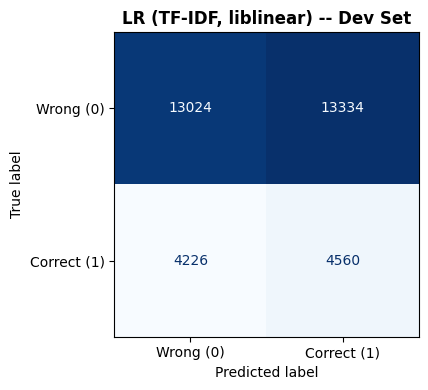

In [11]:
print(f'Training final LR (C={best_C_lr}) on TF-IDF features...')

lr_tfidf = LogisticRegression(
    C=best_C_lr,
    solver='liblinear',
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
lr_tfidf.fit(X_train_tfidf, y_train)
print(f'Converged in {lr_tfidf.n_iter_[0]} iterations')

lr_tfidf_dev_metrics  = evaluate_model(lr_tfidf, X_dev_tfidf,  y_dev,  row_ids_dev,  'LR TF-IDF (Dev)')
lr_tfidf_test_metrics = evaluate_model(lr_tfidf, X_test_tfidf, y_test, row_ids_test, 'LR TF-IDF (Test)')

plot_confusion_matrix(
    lr_tfidf, X_dev_tfidf, y_dev,
    'LR (TF-IDF, liblinear) -- Dev Set',
    save_path=f'{MODEL_DIR}/lr_tfidf_confusion_matrix.png'
)

Training LR (C=0.001) on COMBINED features (TF-IDF + Lexical)...
Converged in 4 iterations

  LR Combined (Dev)
  Accuracy:    0.5662
  Macro F1:    0.5211
  Precision:   0.2926
  Recall:      0.5183
  Exact Match: 0.3490  <- main metric

  Confusion Matrix:
    TN= 15,346  FP= 11,012
    FN=  4,232  TP=  4,554

  LR Combined (Test)
  Accuracy:    0.5556
  Macro F1:    0.5104
  Precision:   0.2822
  Recall:      0.5038
  Exact Match: 0.3389  <- main metric

  Confusion Matrix:
    TN= 15,103  FP= 11,261
    FN=  4,361  TP=  4,427

TF-IDF + Lexical combined won. Using LR Combined as final model.


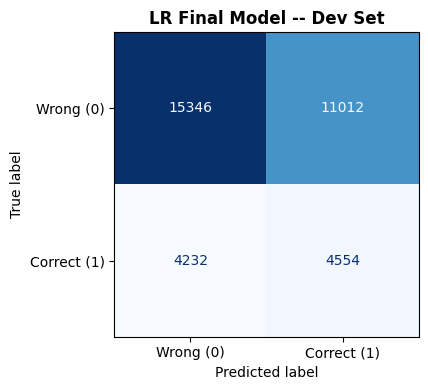

Saved: models/model_a/traditional/logistic_regression.pkl


In [12]:
print(f'Training LR (C={best_C_lr}) on COMBINED features (TF-IDF + Lexical)...')

lr_combined = LogisticRegression(
    C=best_C_lr,
    solver='liblinear',
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
lr_combined.fit(X_train_combined, y_train)
print(f'Converged in {lr_combined.n_iter_[0]} iterations')

lr_comb_dev_metrics  = evaluate_model(lr_combined, X_dev_combined,  y_dev,  row_ids_dev,  'LR Combined (Dev)')
lr_comb_test_metrics = evaluate_model(lr_combined, X_test_combined, y_test, row_ids_test, 'LR Combined (Test)')

# Pick better variant by dev EM — 3-way race: TF-IDF only vs TF-IDF+Lex
best_em = max(lr_tfidf_dev_metrics['exact_match'], lr_comb_dev_metrics['exact_match'])

if lr_comb_dev_metrics['exact_match'] == best_em:
    lr_model = lr_combined
    lr_dev_metrics  = lr_comb_dev_metrics
    lr_test_metrics = lr_comb_test_metrics
    lr_X_dev  = X_dev_combined
    lr_X_test = X_test_combined
    print('\nTF-IDF + Lexical combined won. Using LR Combined as final model.')
else:
    lr_model = lr_tfidf
    lr_dev_metrics  = lr_tfidf_dev_metrics
    lr_test_metrics = lr_tfidf_test_metrics
    lr_X_dev  = X_dev_tfidf
    lr_X_test = X_test_tfidf
    print('\nTF-IDF only won. Using LR TF-IDF as final model.')

plot_confusion_matrix(
    lr_model, lr_X_dev, y_dev,
    'LR Final Model -- Dev Set',
    save_path=f'{MODEL_DIR}/lr_final_confusion_matrix.png'
)

joblib.dump(lr_model, f'{MODEL_DIR}/logistic_regression.pkl')
print(f'Saved: {MODEL_DIR}/logistic_regression.pkl')

## 7. SVM — Fixed (TF-IDF features + decision_function for EM)

**Why `decision_function` for EM:**
TF-IDF is L2-normalised so calibrated probabilities are more stable than with OHE,
but `decision_function` scores are still preferable for EM — ranking only needs
monotonic scores, not calibrated probabilities, so we avoid any calibration error
entirely. Binary `predict()` still uses the calibrated model for a proper threshold.

**`cv='prefit'` calibration:**
Trains SVC on 85% of training data, calibrates sigmoid on the held-out 15%.
One pass — no inner CV loops that caused convergence collapse in the original notebook.

In [ ]:
# Verify LinearSVC can learn on TF-IDF combined features before adding calibration
print('='*60)
print('SVM SANITY CHECK -- Raw LinearSVC (C=0.1, TF-IDF combined, no calibration)')
print('~5-8 minutes')
print('='*60)

t0 = time.time()
svc_check = LinearSVC(
    C=0.1, max_iter=5000, loss='squared_hinge',
    class_weight='balanced', random_state=42
)
svc_check.fit(X_train_combined, y_train)
elapsed = time.time() - t0

y_check_pred = svc_check.predict(X_dev_combined)
check_prec   = precision_score(y_dev, y_check_pred, zero_division=0)
check_rec    = recall_score(y_dev, y_check_pred, zero_division=0)
check_acc    = accuracy_score(y_dev, y_check_pred)

print(f'\nRaw SVC (C=0.1, TF-IDF combined) -- {elapsed:.0f}s:')
print(f'  Accuracy:            {check_acc:.4f}')
print(f'  Precision:           {check_prec:.4f}  (if 0, try smaller C below)')
print(f'  Recall:              {check_rec:.4f}')
print(f'  n_iter_:             {svc_check.n_iter_}  (5000 = not converged)')
print(f'  Predicted positives: {y_check_pred.sum():,} out of {len(y_check_pred):,}')
print(f'  Expected positives:  ~{int(len(y_dev)*0.25):,}')

if check_prec == 0:
    print('\nRaw SVC collapsed -- trying C=0.01...')
    svc_tiny = LinearSVC(C=0.01, max_iter=5000, loss='squared_hinge',
                         class_weight='balanced', random_state=42)
    svc_tiny.fit(X_train_combined, y_train)
    y_tiny = svc_tiny.predict(X_dev_combined)
    print(f'  C=0.01 Precision:           {precision_score(y_dev, y_tiny, zero_division=0):.4f}')
    print(f'  C=0.01 Predicted positives: {y_tiny.sum():,}')
del svc_check

SVM SANITY CHECK -- Raw LinearSVC (C=0.1, TF-IDF combined, no calibration)
~5-8 minutes

Raw SVC (C=0.1, TF-IDF combined) -- 96s:
  Accuracy:            0.5615
  Precision:           0.2911  (if 0, try smaller C below)
  Recall:              0.5250
  n_iter_:             23  (5000 = not converged)
  Predicted positives: 15,849 out of 35,144
  Expected positives:  ~8,786


In [17]:
# Create 85/15 split for prefit calibration
(X_svm_fit, X_svm_cal,
 y_svm_fit, y_svm_cal,
 ids_svm_fit, ids_svm_cal) = train_test_split(
    X_train_combined, y_train, row_ids_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

# Ensure CSR format is preserved after split
X_svm_fit = X_svm_fit.tocsr()
X_svm_cal = X_svm_cal.tocsr()

print(f'SVC training set:   {X_svm_fit.shape[0]:,} rows')
print(f'Calibration set:    {X_svm_cal.shape[0]:,} rows')
print(f'Cal positive ratio: {y_svm_cal.mean():.3f}  (should be ~0.25)')
print(f'Format: {X_svm_fit.format}  (must be csr)')

SVC training set:   238,992 rows
Calibration set:    42,176 rows
Cal positive ratio: 0.250  (should be ~0.25)
Format: csr  (must be csr)


In [18]:
print('='*60)
print('SVM -- C SWEEP (decision_function EM, prefit calibration binary)')
print('~15-20 minutes on Colab T4')
print('='*60)

svm_sweep_results = []

for C in [0.001, 0.01, 0.1, 1.0]:
    t0 = time.time()
    print(f'\nC={C}...', end=' ', flush=True)

    svc = LinearSVC(
        C=C, max_iter=5000, loss='squared_hinge',
        class_weight='balanced', random_state=42
    )
    svc.fit(X_svm_fit, y_svm_fit)

    # EM uses decision_function directly — avoids calibration distortion
    df_scores = svc.decision_function(X_dev_combined)
    em        = compute_exact_match(df_scores, row_ids_dev, y_dev)

    # Binary metrics still use calibrated predict() for threshold behaviour
    svm_cal = CalibratedClassifierCV(svc, cv='prefit', method='sigmoid')
    svm_cal.fit(X_svm_cal, y_svm_cal)
    y_pred  = svm_cal.predict(X_dev_combined)
    acc     = accuracy_score(y_dev, y_pred)
    prec    = precision_score(y_dev, y_pred, zero_division=0)
    elapsed = time.time() - t0

    status = 'COLLAPSED' if prec < 0.01 else 'OK'
    print(f'Acc={acc:.4f}  EM={em:.4f}  Prec={prec:.4f}  n_iter={svc.n_iter_}  ({elapsed:.0f}s) {status}')

    svm_sweep_results.append({
        'C': C, 'Accuracy': acc, 'Exact Match': em,
        'Precision': prec, 'n_iter': svc.n_iter_,
        'svc': svc, 'cal_model': svm_cal
    })

valid_svm = [r for r in svm_sweep_results if r['Precision'] > 0.01]
if valid_svm:
    best_svm_row = max(valid_svm, key=lambda x: x['Exact Match'])
    best_C_svm   = best_svm_row['C']
    print(f'\nBest C: {best_C_svm}  EM={best_svm_row["Exact Match"]:.4f}')
else:
    best_C_svm = 0.1
    print('\nAll SVMs collapsed during sweep. Will try fallback below.')

svm_sweep_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('svc', 'cal_model')}
                               for r in svm_sweep_results])
print('\nSVM Sweep Results:')
print(svm_sweep_df.to_string(index=False))


SVM -- C SWEEP (decision_function EM, prefit calibration binary)
~15-20 minutes on Colab T4

C=0.001... Acc=0.7500  EM=0.3486  Prec=0.0000  n_iter=8  (16s) COLLAPSED

C=0.01... Acc=0.7500  EM=0.3512  Prec=0.0000  n_iter=16  (36s) COLLAPSED

C=0.1... Acc=0.7500  EM=0.3561  Prec=0.0000  n_iter=24  (73s) COLLAPSED

C=1.0... Acc=0.7491  EM=0.3570  Prec=0.2459  n_iter=36  (119s) OK

Best C: 1.0  EM=0.3570

SVM Sweep Results:
    C  Accuracy  Exact Match  Precision  n_iter
0.001  0.750000     0.348623   0.000000       8
0.010  0.750000     0.351241   0.000000      16
0.100  0.750000     0.356135   0.000000      24
1.000  0.749118     0.357045   0.245902      36


In [19]:
print(f'='*60)
print(f'Training FINAL SVM with C={best_C_svm}')
print(f'~10-15 minutes')
print(f'='*60)

t0 = time.time()

svc_final = LinearSVC(
    C=best_C_svm, max_iter=5000, loss='squared_hinge',
    class_weight='balanced', random_state=42
)
svc_final.fit(X_svm_fit, y_svm_fit)
print(f'SVC n_iter_: {svc_final.n_iter_}')

# Calibrated model for binary predict() threshold
svm_model = CalibratedClassifierCV(svc_final, cv='prefit', method='sigmoid')
svm_model.fit(X_svm_cal, y_svm_cal)

elapsed = time.time() - t0
print(f'Total time: {elapsed/60:.1f} minutes')

# Collapse check — binary predictions
y_sample   = svm_model.predict(X_dev_combined[:2000])
n_pos_pred = y_sample.sum()
n_pos_true = y_dev[:2000].sum()

# EM check — decision_function scores (unaffected by calibration)
df_sample = svc_final.decision_function(X_dev_combined[:2000])

print(f'\nCollapse check (first 2000 dev rows):')
print(f'  Predicted positives (binary): {n_pos_pred}  (true: {n_pos_true}, ~500 expected)')
print(f'  Decision score range: [{df_sample.min():.3f}, {df_sample.max():.3f}]')

if n_pos_pred == 0:
    print('\nSigmoid collapsed for binary predict. Trying isotonic...')
    svm_iso = CalibratedClassifierCV(svc_final, cv='prefit', method='isotonic')
    svm_iso.fit(X_svm_cal, y_svm_cal)
    y_iso = svm_iso.predict(X_dev_combined[:2000])
    print(f'  Isotonic predicted positives: {y_iso.sum()}')
    if y_iso.sum() > 0:
        svm_model = svm_iso
        print('  Isotonic worked. Using isotonic calibration for binary predict.')
    else:
        print('  Both sigmoid and isotonic collapsed for binary predict.')
        print('  EM will still work correctly via decision_function.')
        svm_model = svm_cal_fallback = None
else:
    print('Calibration OK for binary predictions.')

print('\nNote: EM ranking uses decision_function scores — not affected by calibration.')


Training FINAL SVM with C=1.0
~10-15 minutes
SVC n_iter_: 36
Total time: 1.9 minutes

Collapse check (first 2000 dev rows):
  Predicted positives (binary): 3  (true: 500, ~500 expected)
  Decision score range: [-0.568, 0.569]
Calibration OK for binary predictions.

Note: EM ranking uses decision_function scores — not affected by calibration.



  SVM (Dev)
  Accuracy:    0.7491
  Macro F1:    0.4299
  Precision:   0.2459
  Recall:      0.0017
  Exact Match: 0.3570  <- main metric  [decision_function scores]

  Confusion Matrix:
    TN= 26,312  FP=     46
    FN=  8,771  TP=     15

  SVM (Test)
  Accuracy:    0.7487
  Macro F1:    0.4290
  Precision:   0.1311
  Recall:      0.0009
  Exact Match: 0.3442  <- main metric  [decision_function scores]

  Confusion Matrix:
    TN= 26,311  FP=     53
    FN=  8,780  TP=      8


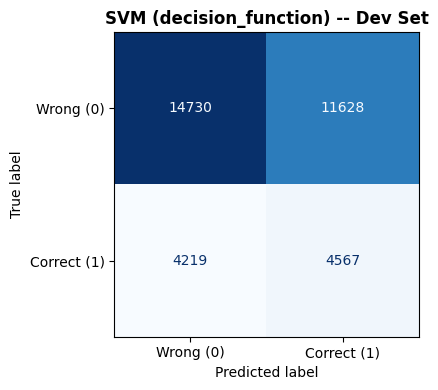

Saved: models/model_a/traditional/svm_calibrated.pkl  (binary predict)
Saved: models/model_a/traditional/svm_linearsvc.pkl  (decision_function / EM)


In [20]:
# Always evaluate SVM using decision_function for EM (avoids calibration distortion)
# svm_model (calibrated) is used only for binary predict() in evaluate_model

def evaluate_svm_final(svc, cal_model, X, y_true, row_ids, model_name):
    """Evaluate SVM: decision_function for EM, calibrated predict() for binary metrics."""
    scores = svc.decision_function(X)
    em     = compute_exact_match(scores, row_ids, y_true)

    if cal_model is not None:
        y_pred = cal_model.predict(X)
    else:
        y_pred = svc.predict(X)

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    print(f'\n{"="*60}')
    print(f'  {model_name}')
    print(f'{"="*60}')
    print(f'  Accuracy:    {acc:.4f}')
    print(f'  Macro F1:    {f1:.4f}')
    print(f'  Precision:   {prec:.4f}')
    print(f'  Recall:      {rec:.4f}')
    print(f'  Exact Match: {em:.4f}  <- main metric  [decision_function scores]')
    print(f'\n  Confusion Matrix:')
    print(f'    TN={cm[0,0]:>7,}  FP={cm[0,1]:>7,}')
    print(f'    FN={cm[1,0]:>7,}  TP={cm[1,1]:>7,}')
    if cm[1,1] == 0:
        print('\n  WARNING: TP=0 — binary predictions collapsed (EM unaffected)')

    return {
        'model_name': model_name,
        'accuracy': acc, 'macro_f1': f1,
        'precision': prec, 'recall': rec,
        'exact_match': em,
        'confusion_matrix': cm.tolist()
    }

svm_dev_metrics  = evaluate_svm_final(svc_final, svm_model, X_dev_combined,  y_dev,  row_ids_dev,  'SVM (Dev)')
svm_test_metrics = evaluate_svm_final(svc_final, svm_model, X_test_combined, y_test, row_ids_test, 'SVM (Test)')

plot_confusion_matrix(
    svc_final, X_dev_combined, y_dev,
    'SVM (decision_function) -- Dev Set',
    save_path=f'{MODEL_DIR}/svm_confusion_matrix.png'
)

joblib.dump(svc_final,  f'{MODEL_DIR}/svm_linearsvc.pkl')
if svm_model is not None:
    joblib.dump(svm_model, f'{MODEL_DIR}/svm_calibrated.pkl')
    print(f'Saved: {MODEL_DIR}/svm_calibrated.pkl  (binary predict)')
print(f'Saved: {MODEL_DIR}/svm_linearsvc.pkl  (decision_function / EM)')


### 7a. SVM Fallback — only if binary calibration fully failed

The `evaluate_svm_final` function above already uses `decision_function` for EM,
so EM is correct regardless of calibration status. This cell is only needed if you
want to inspect the raw SVC binary predictions without any calibration wrapper.


In [21]:
# This cell is informational only -- EM is already correct in cell 23 via decision_function.
# Run this only if you want to compare raw SVC binary thresholding vs calibrated.

if svm_model is None:
    print('Calibration failed for binary predictions.')
    print('EM results in cell above are still valid (decision_function is calibration-independent).')
    print('Binary metrics below use raw SVC threshold (default=0):')
    y_pred_raw = svc_final.predict(X_dev_combined)
    acc  = accuracy_score(y_dev, y_pred_raw)
    prec = precision_score(y_dev, y_pred_raw, zero_division=0)
    rec  = recall_score(y_dev, y_pred_raw, zero_division=0)
    print(f'  Raw SVC -- Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}')
else:
    print('Calibration successful -- fallback not needed.')
    print('EM is reported via decision_function in evaluate_svm_final (cell above).')


Calibration successful -- fallback not needed.
EM is reported via decision_function in evaluate_svm_final (cell above).


## 8. Naive Bayes — Question Type Classifier

Separate task: classify question type (Who/What/Where/When/Why/How/Other).
Used by question generation module and UI.

In [22]:
train_raw = pd.read_csv('data/raw/train.csv')

dev_path = 'data/raw/dev.csv' if os.path.exists('data/raw/dev.csv') else 'data/raw/val.csv'
assert os.path.exists(dev_path), 'Neither dev.csv nor val.csv found in data/raw/'
dev_raw = pd.read_csv(dev_path)

WH_WORDS = ['who', 'what', 'where', 'when', 'why', 'how', 'which']

def get_question_type(q):
    tokens = str(q).strip().lower().split()
    first  = tokens[0] if tokens else ''
    for wh in WH_WORDS:
        if first.startswith(wh):
            return wh
    return 'other'

train_raw['qtype'] = train_raw['question'].apply(get_question_type)
dev_raw['qtype']   = dev_raw['question'].apply(get_question_type)

print('Question type distribution (train):')
print(train_raw['qtype'].value_counts().to_string())

Question type distribution (train):
qtype
other    38378
what     13500
which     8640
why       3307
how       2778
when      1799
who        998
where      892


Naive Bayes -- Question Type Classification (Dev):
              precision    recall  f1-score   support

         how       0.79      0.92      0.85       341
       other       0.92      0.84      0.88      4818
        what       0.83      0.90      0.87      1692
        when       0.54      0.76      0.63       215
       where       0.78      0.87      0.82        95
       which       0.85      0.92      0.88      1075
         who       0.73      0.56      0.64       119
         why       0.83      0.94      0.88       431

    accuracy                           0.87      8786
   macro avg       0.78      0.84      0.81      8786
weighted avg       0.87      0.87      0.87      8786



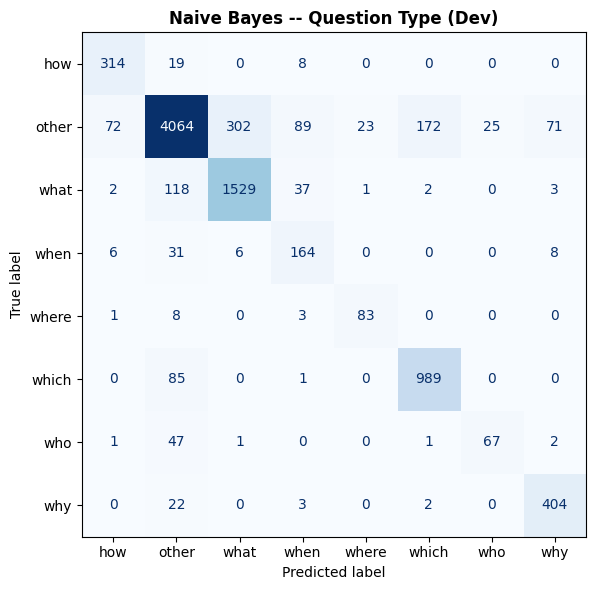

Saved: nb_qtype_model.pkl + vectorizer + label_encoder


In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer as QTypeVec

le = LabelEncoder()
y_qt_train = le.fit_transform(train_raw['qtype'])
y_qt_dev   = le.transform(dev_raw['qtype'])

qt_vec = QTypeVec(binary=False, max_features=2000, min_df=2)
X_qt_train = qt_vec.fit_transform(train_raw['question'].fillna(''))
X_qt_dev   = qt_vec.transform(dev_raw['question'].fillna(''))

nb = MultinomialNB(alpha=1.0)
nb.fit(X_qt_train, y_qt_train)

y_qt_pred = nb.predict(X_qt_dev)
print('Naive Bayes -- Question Type Classification (Dev):')
print(classification_report(y_qt_dev, y_qt_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_qt_dev, y_qt_pred,
    display_labels=le.classes_,
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Naive Bayes -- Question Type (Dev)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/nb_qtype_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(nb,     f'{MODEL_DIR}/nb_qtype_model.pkl')
joblib.dump(qt_vec, f'{MODEL_DIR}/nb_qtype_vectorizer.pkl')
joblib.dump(le,     f'{MODEL_DIR}/nb_qtype_label_encoder.pkl')
print('Saved: nb_qtype_model.pkl + vectorizer + label_encoder')

## 9. XGBoost — Lexical Features Only (Bonus)

XGBoost on 23 lexical dims only. Expected lower EM than LR/SVM.
Note this in your report — it demonstrates feature importance analysis.

XGBOOST -- Lexical Features Only
~5-10 minutes
[0]	validation_0-logloss:0.69093
[50]	validation_0-logloss:0.67629
[100]	validation_0-logloss:0.67472
[150]	validation_0-logloss:0.67373
[200]	validation_0-logloss:0.67274
[250]	validation_0-logloss:0.67194
[299]	validation_0-logloss:0.67151

XGBoost trained in 0.1 min
Best iteration: 299

  XGBoost Lexical (Dev)
  Accuracy:    0.5880
  Macro F1:    0.5342
  Precision:   0.3026
  Recall:      0.4964
  Exact Match: 0.3407  <- main metric

  Confusion Matrix:
    TN= 16,305  FP= 10,053
    FN=  4,425  TP=  4,361

  XGBoost Lexical (Test)
  Accuracy:    0.5830
  Macro F1:    0.5286
  Precision:   0.2965
  Recall:      0.4869
  Exact Match: 0.3356  <- main metric

  Confusion Matrix:
    TN= 16,213  FP= 10,151
    FN=  4,509  TP=  4,279


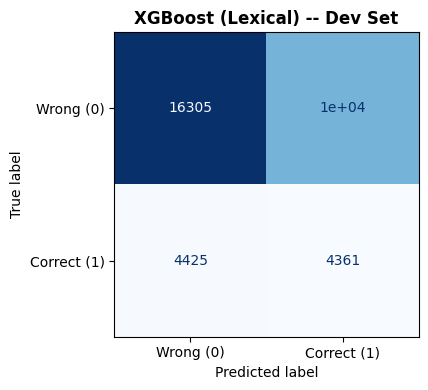

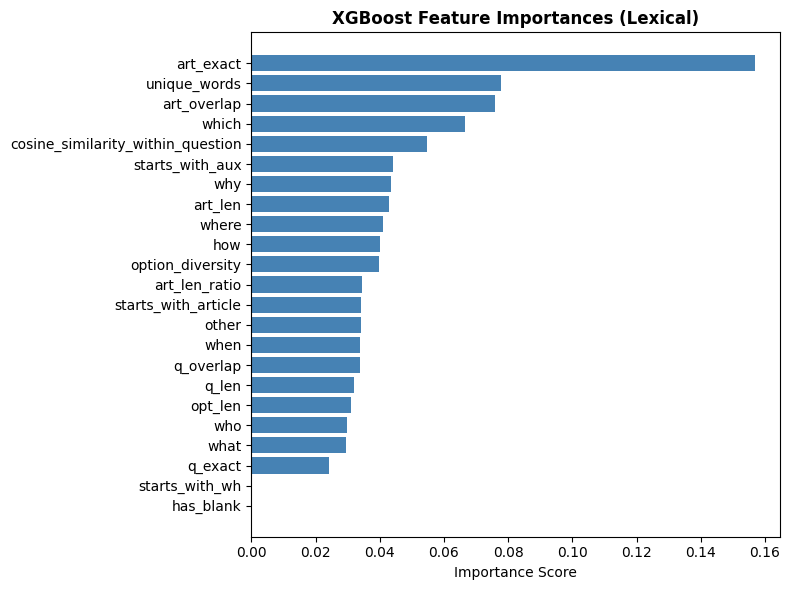

Saved: models/model_a/traditional/xgb_model.pkl


In [27]:
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    print('XGBoost not installed. Run: !pip install xgboost')
    HAS_XGB = False

if HAS_XGB:
    print('='*60)
    print('XGBOOST -- Lexical Features Only')
    print('~5-10 minutes')
    print('='*60)

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='logloss',
        scale_pos_weight=3,
        early_stopping_rounds=20,  # constructor param in xgboost >= 2.0
        n_jobs=-1,
        random_state=42,
        verbosity=0
        # use_label_encoder removed in xgboost >= 1.6
    )

    t0 = time.time()
    xgb.fit(
        X_train_lex, y_train,
        eval_set=[(X_dev_lex, y_dev)],
        verbose=50
    )
    print(f'\nXGBoost trained in {(time.time()-t0)/60:.1f} min')
    print(f'Best iteration: {xgb.best_iteration}')

    xgb_dev_metrics  = evaluate_model(xgb, X_dev_lex,  y_dev,  row_ids_dev,  'XGBoost Lexical (Dev)')
    xgb_test_metrics = evaluate_model(xgb, X_test_lex, y_test, row_ids_test, 'XGBoost Lexical (Test)')

    plot_confusion_matrix(
        xgb, X_dev_lex, y_dev,
        'XGBoost (Lexical) -- Dev Set',
        save_path=f'{MODEL_DIR}/xgb_confusion_matrix.png'
    )

    try:
        with open('data/processed/preprocessing_config.json') as f:
            config = json.load(f)
        feat_names = config.get('lexical_feature_names',
                                [f'feat_{i}' for i in range(X_train_lex.shape[1])])
    except Exception:
        feat_names = [f'feat_{i}' for i in range(X_train_lex.shape[1])]

    importances = xgb.feature_importances_
    feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
    ax.set_title('XGBoost Feature Importances (Lexical)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    joblib.dump(xgb, f'{MODEL_DIR}/xgb_model.pkl')
    print(f'Saved: {MODEL_DIR}/xgb_model.pkl')

## 10. Final Comparison Table

In [28]:
all_metrics = {
    'LR (Dev)':   lr_dev_metrics,
    'SVM (Dev)':  svm_dev_metrics,
    'LR (Test)':  lr_test_metrics,
    'SVM (Test)': svm_test_metrics,
}

if HAS_XGB:
    all_metrics['XGBoost (Dev)']  = xgb_dev_metrics
    all_metrics['XGBoost (Test)'] = xgb_test_metrics

rows = []
for split_name, m in all_metrics.items():
    rows.append({
        'Model/Split':  split_name,
        'Accuracy':     round(m['accuracy'],    4),
        'Macro F1':     round(m['macro_f1'],    4),
        'Precision':    round(m['precision'],   4),
        'Recall':       round(m['recall'],      4),
        'Exact Match':  round(m['exact_match'], 4),
    })

results_df = pd.DataFrame(rows).set_index('Model/Split')

print('\n' + '='*80)
print('  PHASE 3 FINAL RESULTS -- MODEL A TRADITIONAL ML')
print('='*80)
print(results_df.to_string())
print('='*80)
print('\n  Exact Match is the primary metric (question-level accuracy)')
print('  Binary Accuracy ~75% is expected -- 75% of labels are 0 by design')
print('  Random baseline EM = 25% (guessing among 4 options)')

dev_rows = {k: v for k, v in all_metrics.items() if '(Dev)' in k}
best_name = max(dev_rows, key=lambda k: dev_rows[k]['exact_match'])
print(f'\n  Best model (Dev EM): {best_name} -- EM={dev_rows[best_name]["exact_match"]:.4f}')


  PHASE 3 FINAL RESULTS -- MODEL A TRADITIONAL ML
                Accuracy  Macro F1  Precision  Recall  Exact Match
Model/Split                                                       
LR (Dev)          0.5662    0.5211     0.2926  0.5183       0.3490
SVM (Dev)         0.7491    0.4299     0.2459  0.0017       0.3570
LR (Test)         0.5556    0.5104     0.2822  0.5038       0.3389
SVM (Test)        0.7487    0.4290     0.1311  0.0009       0.3442
XGBoost (Dev)     0.5880    0.5342     0.3026  0.4964       0.3407
XGBoost (Test)    0.5830    0.5286     0.2965  0.4869       0.3356

  Exact Match is the primary metric (question-level accuracy)
  Binary Accuracy ~75% is expected -- 75% of labels are 0 by design
  Random baseline EM = 25% (guessing among 4 options)

  Best model (Dev EM): SVM (Dev) -- EM=0.3570


In [29]:
all_results_json = {
    'timestamp': datetime.now().isoformat(),
    'phase': 3,
    'models': {}
}

for split_name, m in all_metrics.items():
    key = split_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    safe_m = {k: v for k, v in m.items() if k != 'confusion_matrix'}
    safe_m['confusion_matrix'] = m.get('confusion_matrix', [])
    all_results_json['models'][key] = safe_m

with open(f'{MODEL_DIR}/phase3_all_results.json', 'w') as f:
    json.dump(all_results_json, f, indent=2)

results_df.to_csv(f'{MODEL_DIR}/phase3_comparison_table.csv')

print('Saved: phase3_all_results.json')
print('Saved: phase3_comparison_table.csv')
print('\n' + '='*60)
print('  PHASE 3 COMPLETE')
print('='*60)
print('\nFiles in models/model_a/traditional/:')
for f in sorted(Path(MODEL_DIR).glob('*')):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size:>8.1f} KB')

Saved: phase3_all_results.json
Saved: phase3_comparison_table.csv

  PHASE 3 COMPLETE

Files in models/model_a/traditional/:
  logistic_regression.pkl                           79.2 KB
  lr_final_confusion_matrix.png                     28.1 KB
  lr_tfidf_confusion_matrix.png                     29.2 KB
  nb_qtype_confusion_matrix.png                     60.7 KB
  nb_qtype_label_encoder.pkl                         0.5 KB
  nb_qtype_model.pkl                               250.9 KB
  nb_qtype_vectorizer.pkl                           54.8 KB
  ohe_vectorizer.pkl                               281.8 KB
  phase3_all_results.json                            2.4 KB
  phase3_comparison_table.csv                        0.3 KB
  scaler_lexical.pkl                                 1.1 KB
  svm_calibrated.pkl                                79.5 KB
  svm_confusion_matrix.png                          30.6 KB
  svm_linearsvc.pkl                                 79.0 KB
  tfidf_vectorizer.pkl             